# LAB 1 - Data Scraping and Preprocessing using Python and Scrapy

## Task 1: Data Scraping

In [23]:
import scrapy

class BookSpider(scrapy.Spider):
    name = 'books'
    allowed_domains = ['books.toscrape.com']
    start_urls = ['https://books.toscrape.com/']
    
    # 1. This forces Scrapy to create the CSV automatically, overwriting old empty ones
    custom_settings = {
        'FEEDS': {
            'books_raw.csv': {
                'format': 'csv',
                'overwrite': True
            }
        },
        # Adds a slight delay to ensure the server doesn't drop our connection
        'DOWNLOAD_DELAY': 0.5, 
    }

    page_count = 1

    def parse(self, response):
        print(f"\n--- SCRAPING CATALOG PAGE {self.page_count} ---\n")
        
        # 2. Extract links to individual books
        book_links = response.css('article.product_pod h3 a::attr(href)').getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        # 3. Handle pagination
        next_page = response.css('li.next a::attr(href)').get()
        if next_page and self.page_count < 6:
            self.page_count += 1
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        # 4. Safe, direct extraction of all required fields
        title = response.css('div.product_main h1::text').get()
        category = response.xpath('//ul[@class="breadcrumb"]/li[3]/a/text()').get()
        price = response.css('p.price_color::text').get()
        
        # Rating requires specific cleaning since it's hidden in the class name
        rating_class = response.css('p.star-rating::attr(class)').get()
        rating = rating_class.replace('star-rating', '').strip() if rating_class else None
        
        # Availability text often has a lot of hidden newline characters
        raw_availability = response.css('p.availability::text').getall()
        availability = "".join(raw_availability).strip()
        
        description = response.xpath('//div[@id="product_description"]/following-sibling::p/text()').get()
        upc = response.xpath('//th[text()="UPC"]/following-sibling::td/text()').get()
        reviews = response.xpath('//th[text()="Number of reviews"]/following-sibling::td/text()').get()

        # 5. Yielding the dictionary writes a row directly to the CSV
        yield {
            'title': title.strip() if title else None,
            'category': category.strip() if category else None,
            'price': price.strip() if price else None,
            'rating': rating,
            'availability': availability,
            'product_description': description.strip() if description else None,
            'UPC': upc.strip() if upc else None,
            'number_of_reviews': reviews.strip() if reviews else None,
            'product_url': response.url
        }

## Task 2: Data Preprocessing

In [24]:
import pandas as pd
import numpy as np

def preprocess_books(input_csv, output_csv):
    print("Loading the raw data...")
    df = pd.read_csv(input_csv)

    # 1. This loop should ONLY contain the strip() function
    str_cols = df.select_dtypes(include=['object']).columns
    for col in str_cols:
        df[col] = df[col].apply(lambda x: str(x).strip() if pd.notnull(x) else x)

    # 2. UN-INDENTED: Everything below here runs only once!
    initial_count = len(df)
    df = df.drop_duplicates(subset=['UPC'], keep='first')
    print(f"Dropped {initial_count - len(df)} duplicate rows based on UPC.")

    df['product_description'] = df['product_description'].fillna("No description available.")
    df['price'] = df['price'].astype(str).str.extract(r'(\d+\.\d+)').astype(float)
    
    # Now this will only run once and keep your numbers intact
    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    df['rating'] = df['rating'].map(rating_map)

    df['stock_count'] = df['availability'].astype(str).str.extract(r'(\d+)').astype(float)
    df['stock_count'] = df['stock_count'].fillna(0).astype(int)

    df['description_word_count'] = df['product_description'].apply(lambda x: len(str(x).split()))

    df['price_band'] = pd.qcut(df['price'], q=3, labels=['Budget', 'Mid-Range', 'Premium'])

    df['value_score'] = (df['rating'] / (df['price'] + 0.01)).round(3)

    df.to_csv(output_csv, index=False)
    print(f"Preprocessing Complete. Cleaned data saved to '{output_csv}'.")

    print("-" * 40)
    print("CLEANED DATASET PREVIEW:")
    print("-" * 40)
    print(df[['title', 'price', 'rating', 'stock_count', 'value_score']].head())

if __name__ == "__main__":
    preprocess_books('books_raw.csv', 'books_cleaned.csv')

Loading the raw data...
Dropped 0 duplicate rows based on UPC.
Preprocessing Complete. Cleaned data saved to 'books_cleaned.csv'.
----------------------------------------
CLEANED DATASET PREVIEW:
----------------------------------------
                                               title  price  rating  \
0                            It's Only the Himalayas  45.17       2   
1                       Libertarianism for Beginners  51.33       2   
2  Mesaerion: The Best Science Fiction Stories 18...  37.59       1   
3                                               Olio  23.88       1   
4  Our Band Could Be Your Life: Scenes from the A...  57.25       3   

   stock_count  value_score  
0           19        0.044  
1           19        0.039  
2           19        0.027  
3           19        0.042  
4           19        0.052  


## Task 3: Visualization and Analysis

Loading cleaned data...
Generating the 2x3 Visualization Grid...


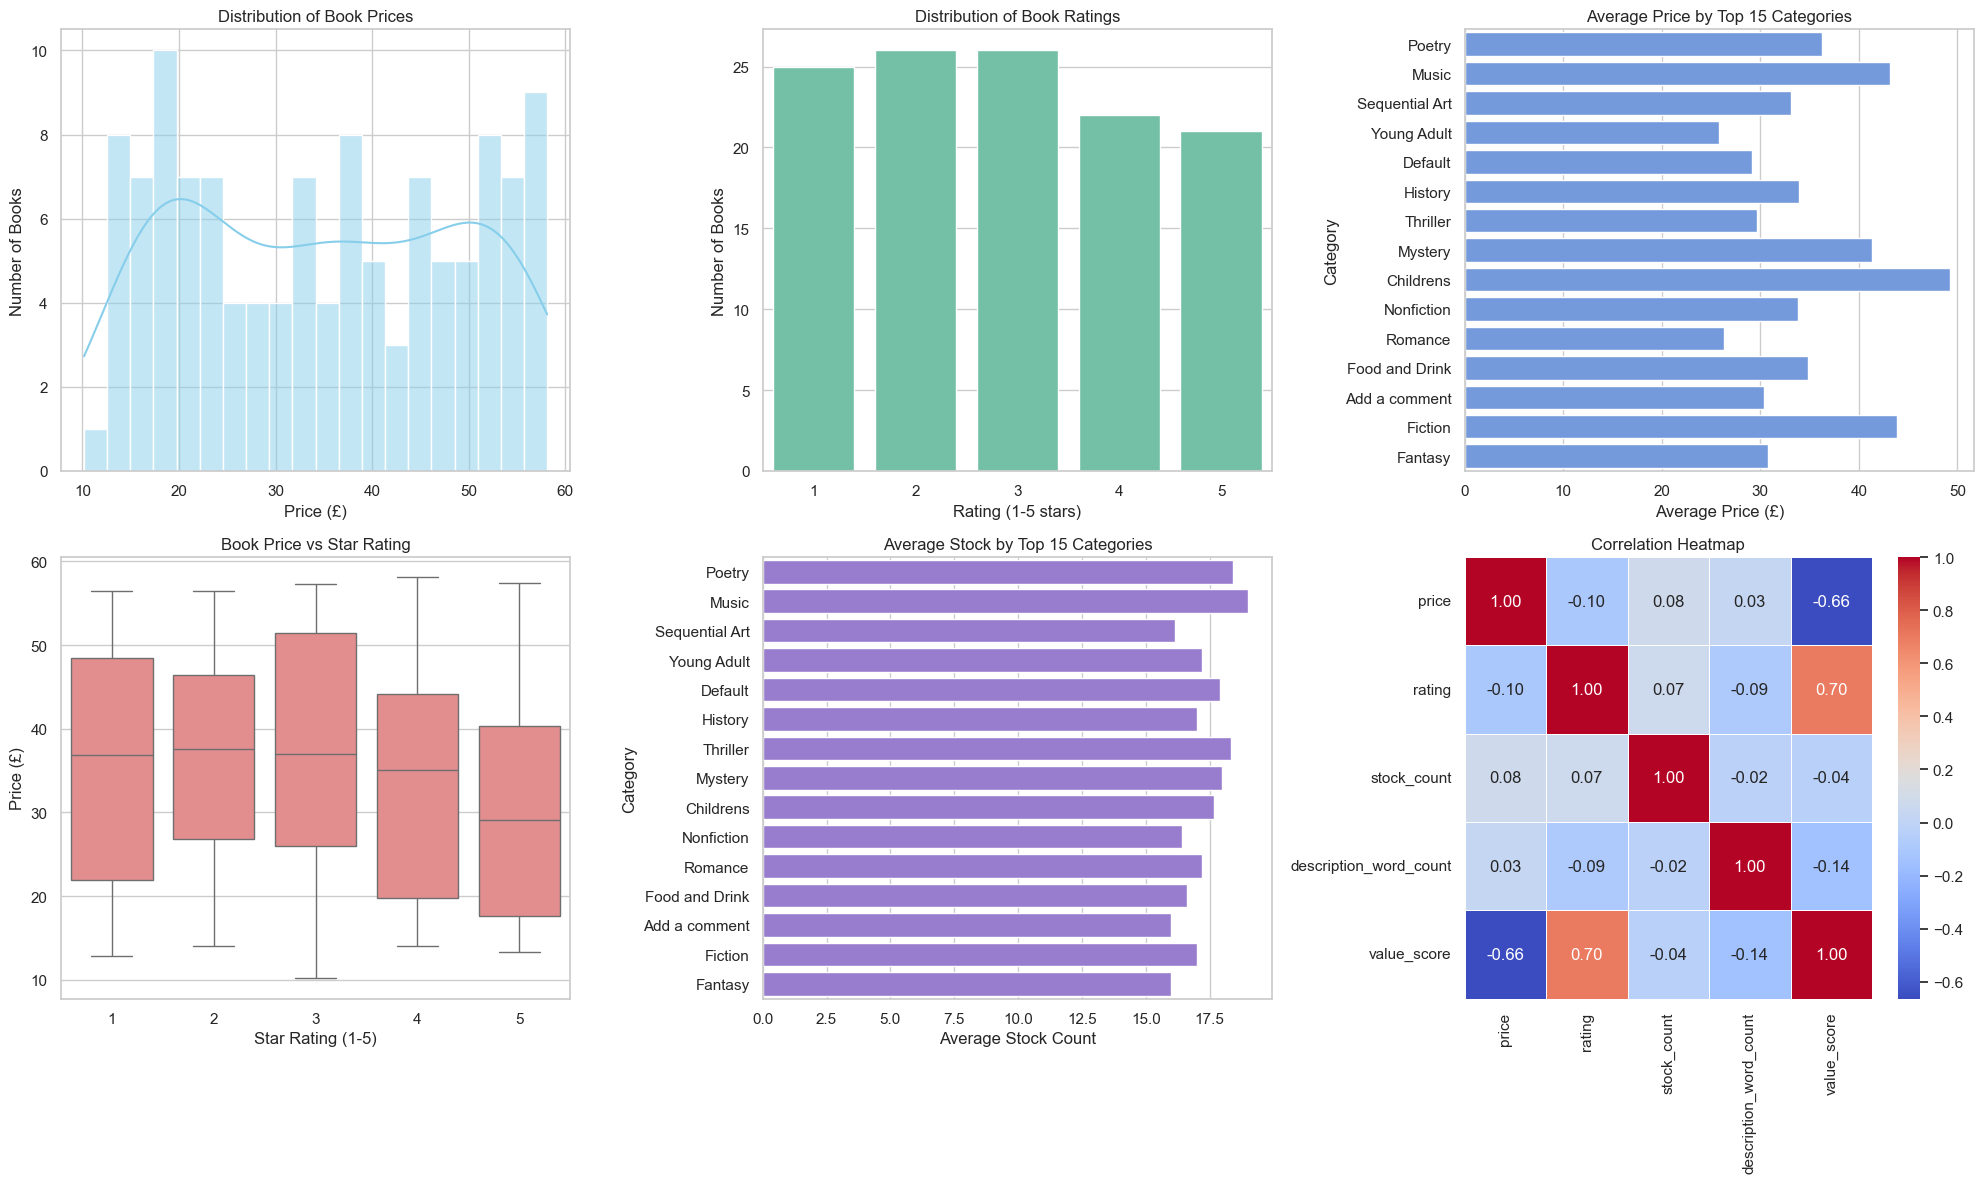

Generating Word Cloud...


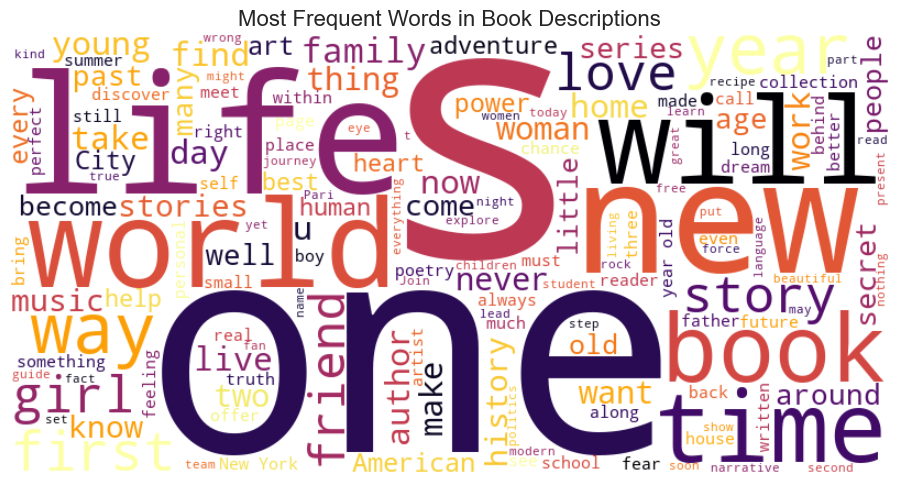


Success! Grid and Word Cloud have been saved and displayed.


In [25]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def generate_visualizations(csv_file):
    print("Loading cleaned data...")
    df = pd.read_csv(csv_file)

    sns.set_theme(style="whitegrid")
    
    print("Generating the 2x3 Visualization Grid...")
    
    # Set up the grid (2 rows, 3 columns) and make the figure large enough
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
    
    # Pre-calculate data needed for multiple plots
    top_categories = df['category'].value_counts().nlargest(15).index
    df_top_cats = df[df['category'].isin(top_categories)]
    plot_df = df.dropna(subset=['rating', 'price'])
    numeric_cols = ['price', 'rating', 'stock_count', 'description_word_count', 'value_score']
    correlation_matrix = df[numeric_cols].corr()

    # Top Left [0, 0]: Price Distribution
    sns.histplot(df['price'], bins=20, kde=True, color='skyblue', ax=axes[0, 0])
    axes[0, 0].set_title('Distribution of Book Prices')
    axes[0, 0].set_xlabel('Price (£)')
    axes[0, 0].set_ylabel('Number of Books')

    # Top Middle [0, 1]: Rating Distribution
    sns.countplot(x='rating', data=df, color='mediumaquamarine', ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of Book Ratings')
    axes[0, 1].set_xlabel('Rating (1-5 stars)')
    axes[0, 1].set_ylabel('Number of Books')

    # Top Right [0, 2]: Average Price by Category
    sns.barplot(x='price', y='category', data=df_top_cats, errorbar=None, color='cornflowerblue', ax=axes[0, 2])
    axes[0, 2].set_title('Average Price by Top 15 Categories')
    axes[0, 2].set_xlabel('Average Price (£)')
    axes[0, 2].set_ylabel('Category')

    # Bottom Left [1, 0]: Price vs Rating
    sns.boxplot(x='rating', y='price', data=plot_df, color='lightcoral', ax=axes[1, 0])
    axes[1, 0].set_title('Book Price vs Star Rating')
    axes[1, 0].set_xlabel('Star Rating (1-5)')
    axes[1, 0].set_ylabel('Price (£)')

    # Bottom Middle [1, 1]: Average Stock by Category
    sns.barplot(x='stock_count', y='category', data=df_top_cats, errorbar=None, color='mediumpurple', ax=axes[1, 1])
    axes[1, 1].set_title('Average Stock by Top 15 Categories')
    axes[1, 1].set_xlabel('Average Stock Count')
    axes[1, 1].set_ylabel('Category')

    # Bottom Right [1, 2]: Correlation Heatmap
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1, 2])
    axes[1, 2].set_title('Correlation Heatmap')

    # Adjust layout so labels don't overlap, save, and display
    plt.tight_layout()
    plt.savefig('combined_6_plots_grid.png')
    plt.show()

    print("Generating Word Cloud...")
    text_data = " ".join(description for description in df['product_description'].dropna())
    
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='inferno',
                          max_words=150).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('Most Frequent Words in Book Descriptions', fontsize=16)
    plt.tight_layout()
    plt.savefig('plot_5_wordcloud.png')
    plt.show()

    print("\nSuccess! Grid and Word Cloud have been saved and displayed.")

if __name__ == "__main__":
    generate_visualizations('books_cleaned.csv')

In [26]:
print("=" * 50)
print(" EXPLORATORY DATA ANALYSIS & SUMMARY STATISTICS ")
print("=" * 50)

df = pd.read_csv('books_cleaned.csv')
print("Cleaned data successfully loaded. Ready for analysis.")

 EXPLORATORY DATA ANALYSIS & SUMMARY STATISTICS 
Cleaned data successfully loaded. Ready for analysis.


In [ ]:
print("--- 1. MISSING & UNUSUAL VALUES ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "No missing values detected in the cleaned dataset.")

free_books = len(df[df['price'] == 0])
print(f"Number of books priced at £0.00: {free_books}")

print("\n\n--- 2. NUMERIC DISTRIBUTION ---")
numeric_summary = df[['price', 'rating', 'stock_count', 'description_word_count']].describe().round(2)
print(numeric_summary)

--- 1. MISSING & UNUSUAL VALUES ---
No missing values detected in the cleaned dataset.
Number of books priced at £0.00: 0
--- 2. NUMERIC DISTRIBUTION ---
        price  rating  stock_count  description_word_count
count  120.00  120.00       120.00                  120.00
mean    34.85    2.90        16.98                  225.58
std     14.32    1.39         1.42                  101.13
min     10.16    1.00        16.00                   36.00
25%     21.64    2.00        16.00                  165.75
50%     34.78    3.00        16.00                  213.00
75%     47.97    4.00        18.00                  271.75
max     58.11    5.00        22.00                  722.00


In [ ]:
print("--- 3. CATEGORY PATTERNS ---")
total_categories = df['category'].nunique()
print(f"Total unique categories scraped: {total_categories}")

print("\nTop 5 Most Represented Categories:")
print(df['category'].value_counts().head(5))

print("\n\n--- 4. HIGHLY RATED BOOKS (4 & 5 Stars) ---")
highly_rated = df[df['rating'] >= 4]
percent_highly_rated = (len(highly_rated) / len(df)) * 100

print(f"Total highly rated books: {len(highly_rated)} ({percent_highly_rated:.1f}% of scraped dataset)")
print(f"Average price of a highly rated book: £{highly_rated['price'].mean():.2f}")
print(f"Average price of lower-rated books (1-3 stars): £{df[df['rating'] < 4]['price'].mean():.2f}")

--- 3. CATEGORY PATTERNS ---
Total unique categories scraped: 30

Top 5 Most Represented Categories:
category
Sequential Art    21
Nonfiction        14
Default           10
Poetry             7
Fantasy            6
Name: count, dtype: int64
--- 4. HIGHLY RATED BOOKS (4 & 5 Stars) ---
Total highly rated books: 43 (35.8% of scraped dataset)
Average price of a highly rated book: £32.33
Average price of lower-rated books (1-3 stars): £36.25


In [29]:
print("--- 5. STOCK PATTERNS ---")
print(f"Total inventory across all scraped books: {df['stock_count'].sum()} units")
print(f"Maximum stock for a single book: {df['stock_count'].max()} units")

out_of_stock = len(df[df['stock_count'] == 0])
print(f"Books currently out of stock: {out_of_stock}")

# Find the category with the highest average stock
cat_stock = df.groupby('category')['stock_count'].mean().sort_values(ascending=False)
print(f"\nCategory with highest average stock: '{cat_stock.index[0]}' ({cat_stock.iloc[0]:.1f} units/book)")

--- 5. STOCK PATTERNS ---
Total inventory across all scraped books: 2038 units
Maximum stock for a single book: 22 units
Books currently out of stock: 0

Category with highest average stock: 'Business' (19.0 units/book)


## Task 4: Insights and Interpretation


-> The first plot shows the distribution of the Book Prices ranging from 10 to 60 and the count of books reaching the maximum of 10 when the price is about 17.5 to 20, there is also a line that is the Kernel Density Estimate (kde) which showcases the smoothed, overall shape and trend of the distribution.


-> The second plot shows the distribution of the book ratings, wherein we can see the count or the number of the books as per each rating ranging from 1 to 5.

-> The third and the fifth plot showcase the Average Price and Average Stock of the Top 15 categories respectively.

-> The fourth plot is the Box Plot, the spread of book prices remains remarkably consistent regardless of the star rating. There is no clear correlation between the two metrics, highlighted by the fact that 1-star books have a higher median price (£37) than 5-star books (£29).

-> The sixth plot is the heatmap which showcases the correlation of the different attributes with each other like Price, Rating, Stock Count, Description Word Count, Value Score

    With the help of which we can see that the Price and the Value Score have a Negative Correlation.

    And even the Rating and the Value Score have a Positive Correlation

### Summary Statistics

-> It represents the Numerical Distribution, along with the Top 5 Most Represented Categories, and even that 1/3rd of the books are highly rated with a rating of 4 or 5.

### Limitation of the Dataset 

1. As we can see the heatmap, which shows that there is lack of correlation between the price and rating, so we are unable to derive any meaningful insights from it.

2. As we are using only sample or nearly 10% of the entire dataset, which means there is very limited amount to make actual insights and show correlation. 

3. It is not a real time data, so we cannot timely update it which makes it redundant after some point of time.